<a href="https://colab.research.google.com/github/ham-codes7/Exploratory-Data-Analysis-/blob/main/Exp8_01_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Image dimensions: 28 x 28 (flattened to {X.shape[1]})")

Number of samples: 70000
Number of classes: 10
Image dimensions: 28 x 28 (flattened to 784)


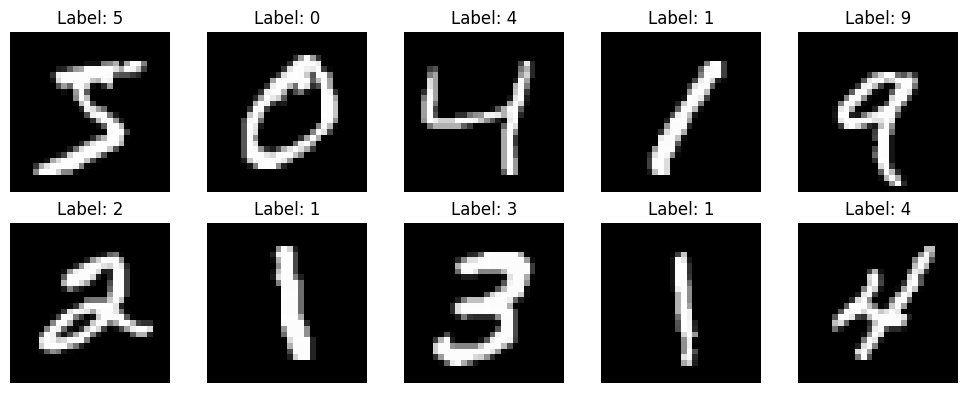

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
X_norm = X / 255.0

In [5]:
X_sub, _, y_sub, _ = train_test_split(X_norm, y, train_size=10000, stratify=y, random_state=42)
print(f"Working subset shape: {X_sub.shape}")

Working subset shape: (10000, 784)


In [6]:
pca_full = PCA()
pca_full.fit(X_sub)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

In [7]:
for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cum_var >= threshold) + 1
    print(f"Components for {int(threshold*100)}% variance: {n_components}")

Components for 90% variance: 86
Components for 95% variance: 151
Components for 99% variance: 325


In [8]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_sub)
pca_50d = PCA(n_components=50)
X_pca_50d = pca_50d.fit_transform(X_sub)

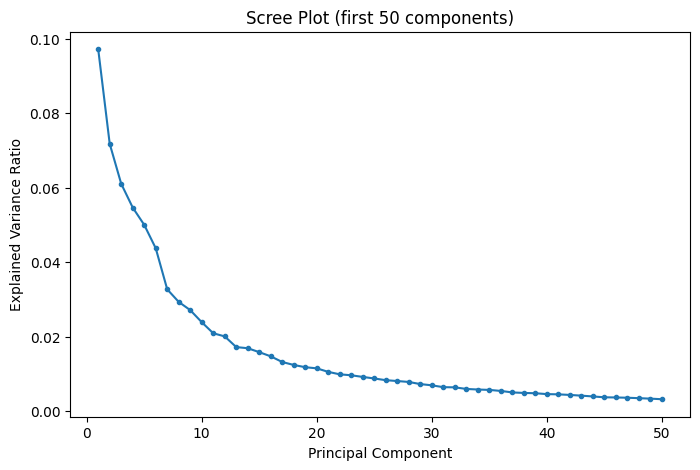

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), explained_var[:50], marker='o', markersize=3)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (first 50 components)")
plt.show()

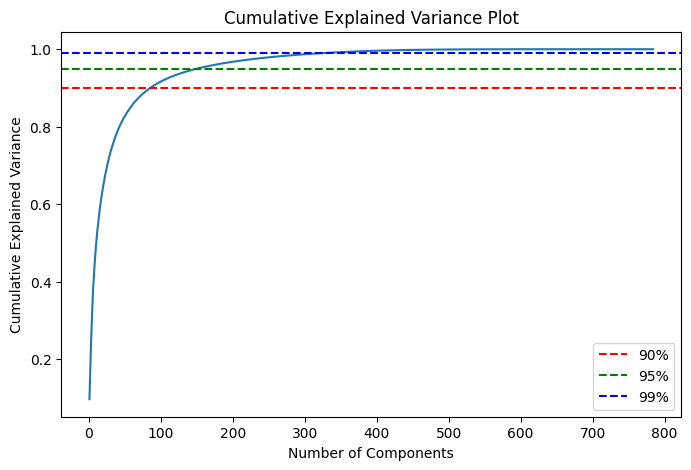

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var)
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.axhline(0.95, color='g', linestyle='--', label='95%')
plt.axhline(0.99, color='b', linestyle='--', label='99%')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.legend()
plt.show()

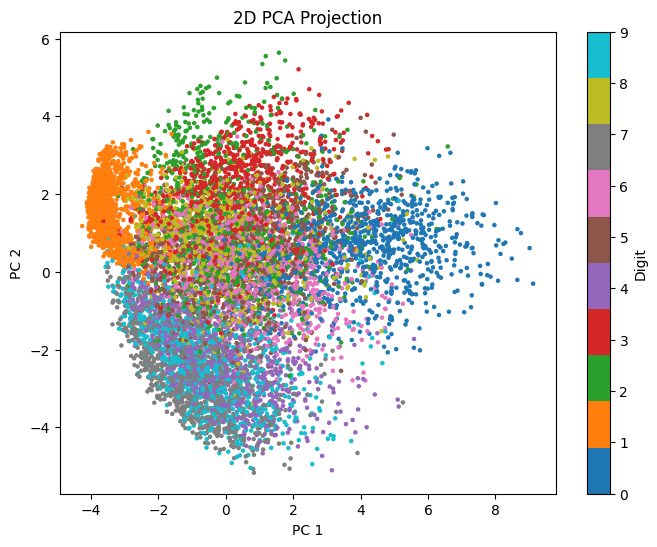

In [11]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_sub, cmap='tab10', s=5)
plt.colorbar(scatter, label='Digit')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("2D PCA Projection")
plt.show()

In [12]:
tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne_orig = tsne_orig.fit_transform(X_sub)

tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne_pca = tsne_pca.fit_transform(X_pca_50d)

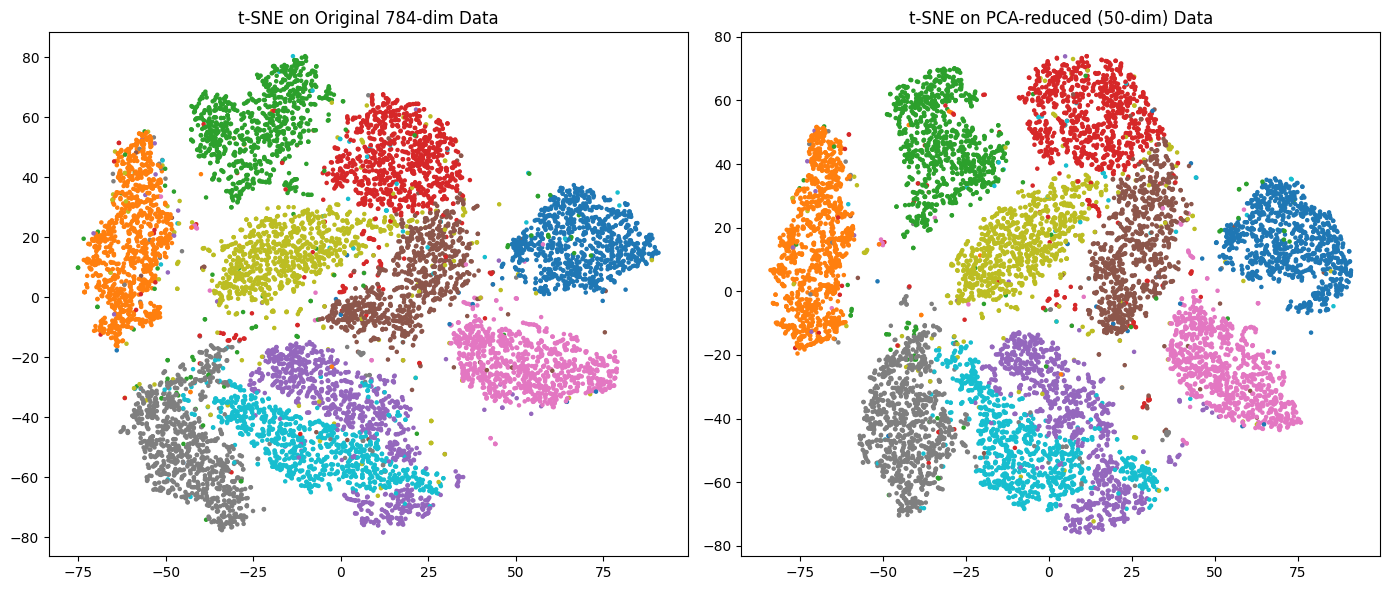

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_tsne_orig[:, 0], X_tsne_orig[:, 1], c=y_sub, cmap='tab10', s=5)
axes[0].set_title("t-SNE on Original 784-dim Data")
axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y_sub, cmap='tab10', s=5)
axes[1].set_title("t-SNE on PCA-reduced (50-dim) Data")
plt.tight_layout()
plt.show()

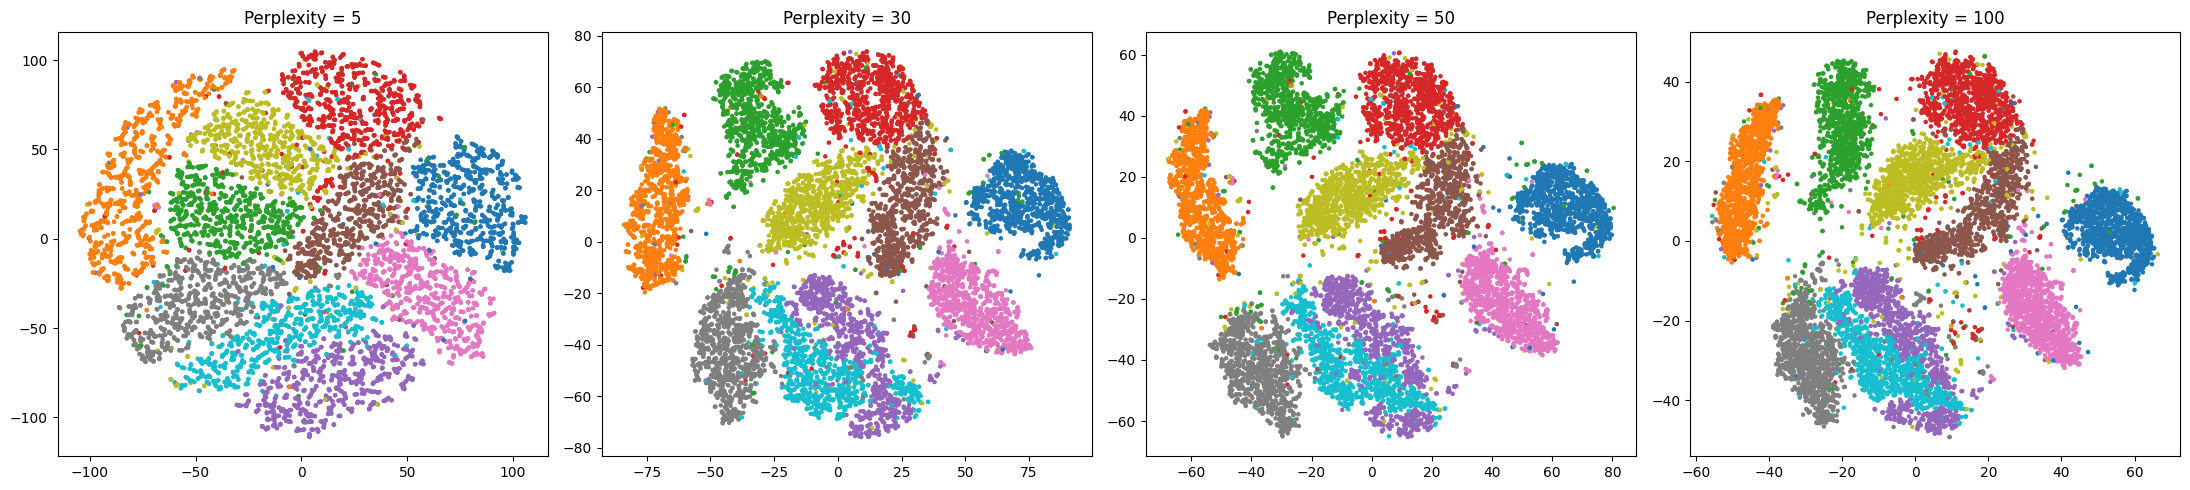

In [14]:
perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for idx, p in enumerate(perplexities):
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=42, init='pca')
    X_tsne_p = tsne_p.fit_transform(X_pca_50d)
    axes[idx].scatter(X_tsne_p[:, 0], X_tsne_p[:, 1], c=y_sub, cmap='tab10', s=5)
    axes[idx].set_title(f"Perplexity = {p}")
plt.tight_layout()
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)
pca_clf = PCA(n_components=50)
X_train_pca = pca_clf.fit_transform(X_train)
X_test_pca = pca_clf.transform(X_test)
print(f"Train shape (original): {X_train.shape}, Train shape (PCA): {X_train_pca.shape}")

Train shape (original): (8000, 784), Train shape (PCA): (8000, 50)


In [16]:
def evaluate_classifier(clf, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0
    t0 = time.time()
    y_pred = clf.predict(X_te)
    pred_time = time.time() - t0
    acc = accuracy_score(y_te, y_pred)
    return acc, train_time, pred_time

In [17]:
knn_orig_acc, knn_orig_train, knn_orig_pred = evaluate_classifier(KNeighborsClassifier(), X_train, y_train, X_test, y_test)
knn_pca_acc, knn_pca_train, knn_pca_pred = evaluate_classifier(KNeighborsClassifier(), X_train_pca, y_train, X_test_pca, y_test)
print(f"KNN Original: acc={knn_orig_acc:.4f}, train_time={knn_orig_train:.4f}s, pred_time={knn_orig_pred:.4f}s")
print(f"KNN PCA-50: acc={knn_pca_acc:.4f}, train_time={knn_pca_train:.4f}s, pred_time={knn_pca_pred:.4f}s")

KNN Original: acc=0.9435, train_time=0.0123s, pred_time=0.9714s
KNN PCA-50: acc=0.9555, train_time=0.0013s, pred_time=0.1260s


In [18]:
svm_orig_acc, svm_orig_train, svm_orig_pred = evaluate_classifier(SVC(), X_train, y_train, X_test, y_test)
svm_pca_acc, svm_pca_train, svm_pca_pred = evaluate_classifier(SVC(), X_train_pca, y_train, X_test_pca, y_test)
print(f"SVM Original: acc={svm_orig_acc:.4f}, train_time={svm_orig_train:.4f}s, pred_time={svm_orig_pred:.4f}s")
print(f"SVM PCA-50: acc={svm_pca_acc:.4f}, train_time={svm_pca_train:.4f}s, pred_time={svm_pca_pred:.4f}s")

SVM Original: acc=0.9570, train_time=7.7451s, pred_time=6.7747s
SVM PCA-50: acc=0.9615, train_time=1.8327s, pred_time=0.5781s


In [19]:
import pandas as pd
comparison = pd.DataFrame({
    "Classifier": ["KNN", "KNN", "SVM", "SVM"],
    "Data": ["Original (784-dim)", "PCA (50-dim)", "Original (784-dim)", "PCA (50-dim)"],
    "Accuracy": [knn_orig_acc, knn_pca_acc, svm_orig_acc, svm_pca_acc],
    "Train Time (s)": [knn_orig_train, knn_pca_train, svm_orig_train, svm_pca_train],
    "Pred Time (s)": [knn_orig_pred, knn_pca_pred, svm_orig_pred, svm_pca_pred]
})
comparison

,Classifier,Data,Accuracy,Train Time (s),Pred Time (s)
0,KNN,Original (784-dim),0.9435,0.012338,0.971403
1,KNN,PCA (50-dim),0.9555,0.001318,0.126032
2,SVM,Original (784-dim),0.9570,7.745102,6.774680
3,SVM,PCA (50-dim),0.9615,1.832698,0.578114
